In [1]:
from langgraph.graph import StateGraph, START, END, MessagesState


In [2]:
from langchain.chat_models import init_chat_model


In [3]:
model_id="gemini-2.5-flash-preview-05-20"
llm = init_chat_model(model=model_id,  model_provider="google_vertexai")

In [4]:
# llm

async for event in llm.astream_events("Hi this is khaja. What is latest update by google vertex"):
    if event["event"] == "on_chat_model_stream":
        print(event["data"]["chunk"].content)

Hi Khaja!

Google's Vertex AI platform is constantly evolving, with a strong focus on Generative AI, MLOps, and responsible AI. While "latest" can change daily with rolling updates, here's a summary of the most significant and recent advancements, especially those announced at major events like Google
 Cloud Next and Google I/O:

The overarching theme for Vertex AI updates is to make it easier for developers and data scientists to build, deploy, and scale AI models, particularly large language models (LLMs) and other generative models, in a responsible way.

Here are the key areas of recent updates:

1.
  **Generative AI Enhancements (The Biggest Focus):**
    *   **Gemini Models:** The most significant update is the broader availability of **Gemini models** (Nano, Pro, Ultra, and specialized versions like Flash) within Vertex AI.
        *   **Multimodality:** Gemini brings
 native multimodal capabilities, allowing it to understand and generate text, images, audio, and video directly.

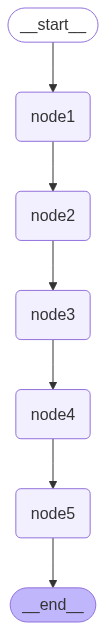

In [5]:
from typing import TypedDict
class MyState(TypedDict):
    message: str

from time import sleep
def node_1(state: MyState) -> MyState:
    state['message'] = "Im in node 1"
    sleep(2)
    return state

def node_2(state: MyState) -> MyState:
    state['message'] = "Im in node 2"
    sleep(2)
    return state

def node_3(state: MyState) -> MyState:
    state['message'] = "Im in node 3"
    sleep(2)
    return state

def node_4(state: MyState) -> MyState:
    state['message'] = "Im in node 4"
    sleep(2)
    return state

def node_5(state: MyState) -> MyState:
    state['message'] = "Im in node 5"
    sleep(2)
    return state

my_graph_builder = StateGraph(MyState)
my_graph_builder.add_node("node1", node_1)
my_graph_builder.add_node("node2", node_2)
my_graph_builder.add_node("node3", node_3)
my_graph_builder.add_node("node4", node_4)
my_graph_builder.add_node("node5", node_5)
my_graph_builder.set_entry_point("node1")
my_graph_builder.set_finish_point("node5")
my_graph_builder.add_edge("node1", "node2")
my_graph_builder.add_edge("node2", "node3")
my_graph_builder.add_edge("node3", "node4")
my_graph_builder.add_edge("node4", "node5")
my_graph = my_graph_builder.compile()

from utils import draw_graph
draw_graph(my_graph)


In [6]:
async for event in my_graph.astream_events({"message": ""}):
    # if event["event"] == "on_chain_stream" and event['data']['chunk']:
    #     print(f"{event['name']} response = {event['data']['chunk']}")
    if event["event"] == 'on_chain_end':
        print(event['data']['output']['message'])

Im in node 1
Im in node 2
Im in node 3
Im in node 4
Im in node 5
Im in node 5


In [7]:
async for event in my_graph.astream_events({"message": ""}):
    if event["event"] == "on_chain_stream" and event['data']['chunk']:
        print(f"{event['name']} response = {event['data']['chunk']}")

node1 response = {'message': 'Im in node 1'}
LangGraph response = {'node1': {'message': 'Im in node 1'}}
node2 response = {'message': 'Im in node 2'}
LangGraph response = {'node2': {'message': 'Im in node 2'}}
node3 response = {'message': 'Im in node 3'}
LangGraph response = {'node3': {'message': 'Im in node 3'}}
node4 response = {'message': 'Im in node 4'}
LangGraph response = {'node4': {'message': 'Im in node 4'}}
node5 response = {'message': 'Im in node 5'}
LangGraph response = {'node5': {'message': 'Im in node 5'}}
